Assignment 2: Graph Visualization

Author: Chi Hang(Philip) Cheung

This week's assignment is to:

1. Load a graph database of your choosing from a text file or other source.  If you take a large network dataset from the web (such as from Stanford Large Network Dataset Collection), please feel free at this point to load just a small subset of the nodes and edges.
    
    a) Used: https://snap.stanford.edu/data/ca-HepTh.html
    
2. Create basic analysis on the graph, including the graph’s diameter, and at least one other metric of your choosing.  You may either code the functions by hand (to build your intuition and insight), or use functions in an existing package. 
3. Use a visualization tool of your choice (Neo4j, Gephi, etc.) to display information.
Please record a short video (~ 5 minutes), and submit a link to the video in advance of our meet-up.

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import gzip

In [2]:
# Read the txt file into pandas dataframe for faster speed:
df = pd.read_csv('CA-HepTh.txt.gz', compression='gzip', header=None, sep='\t', comment='#', names=['Source', 'Target'])

#Create graph:
G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.DiGraph())

print(f'nodes:{G.number_of_nodes()}')
print(f'Edges:{G.number_of_edges()}')

nodes:9877
Edges:51971


Only visualize the top 100 nodes:

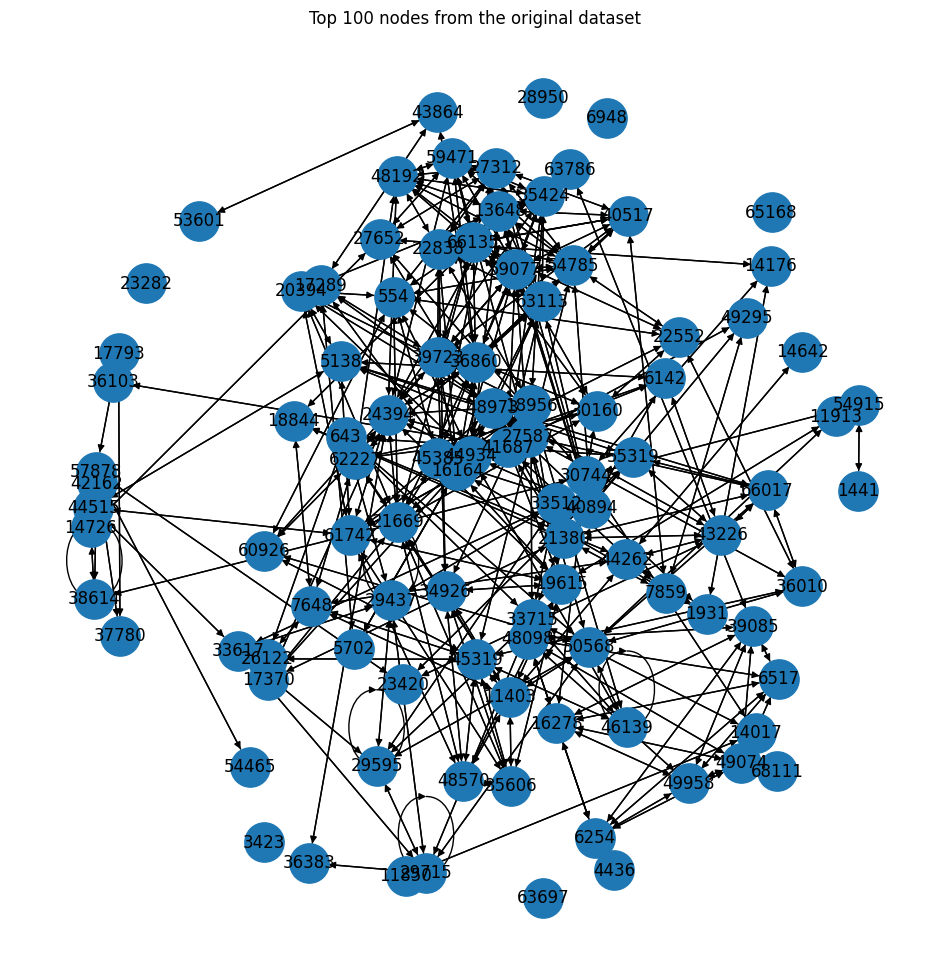

In [20]:
degrees = dict(G.degree())

#Sort the nodes by degree:
my_top_100 = sorted(degrees, key=degrees.get, reverse=True)[:100]

#Create a subgraph of the top 100 nodes with the highest degrees:
subgraph = G.subgraph(my_top_100)

#Create the graph layout:
plt.figure(figsize=(12, 12))
plt.title('Top 100 nodes from the original dataset')
pos = nx.spring_layout(subgraph, k=1.5, iterations=100)
nx.draw(subgraph, pos, with_labels=True, node_size=800)

****************************************************************
Let's find the node with the most connection in the original dataset:

The node with the most number of connection is #: 1441 and the number of connection is :130
--------------------------------------------------------------------------------


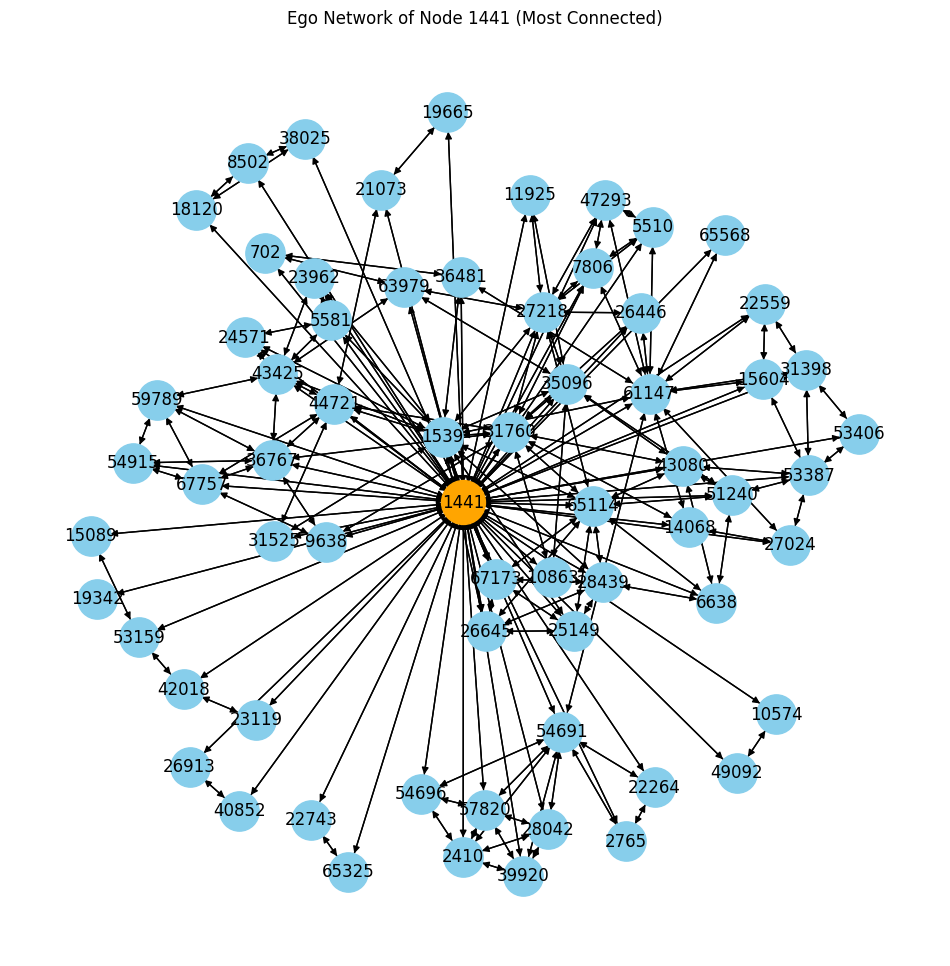

In [ ]:
#Define the node number that has the most connection
top_node = sorted(G.degree(), key=lambda x:x[1], reverse=True)[0]

print(f'The node with the most number of connection is #: {top_node[0]} and the number of connection is :{top_node[1]}')
print('-'*80)

#To create a graph with the top node and its edges:
ego_net = nx.ego_graph(G, top_node[0])

plt.figure(figsize=(12,12))
plt.title('The top node and its connections')
pos = nx.spring_layout(ego_net, seed=42)

nx.draw(ego_net, pos, with_labels=True, node_color='skyblue', node_size=800)

#To highlight the central node in a different color:
nx.draw_networkx_nodes(ego_net, pos, nodelist=[top_node[0]], node_color='orange', node_size=1000)
plt.title(f"Ego Network of Node {top_node[0]} (Most Connected)")
plt.show()

The diameter of the central node:

In [32]:
print(f'The max distance from the central node network is {nx.diameter(ego_net.to_undirected())} nodes away')


The max distance from the central node network is 2 nodes away


********************************************************************************************************************************
To identify the largest connection island from the original graph:

In [47]:
#We have to convert the graph from directed to undirected:
undirect_g = G.to_undirected()

components = sorted(nx.connected_components(undirect_g), key=len, reverse=True) #This returns groups of nodes that are connected together.
biggest_component = components[0] #This will get only the biggest 'island' of nodes that are connected

#Create a graph containing only those nodes and their edges:
lcc = undirect_g.subgraph(biggest_component)

print(f'the diameter of the biggest island(Nodes:{len(biggest_component)} is {nx.diameter(lcc)})')


the diameter of the biggest island(Nodes:8638 is 18)


In [57]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f'Average number of connections per node: {avg_degree:.2f}')

Average number of connections per node: 10.52


### The average connection is considered as very high because the diameter of the biggest island is 18, and on average, each node has about 10 connections--almost reaching one end from the other

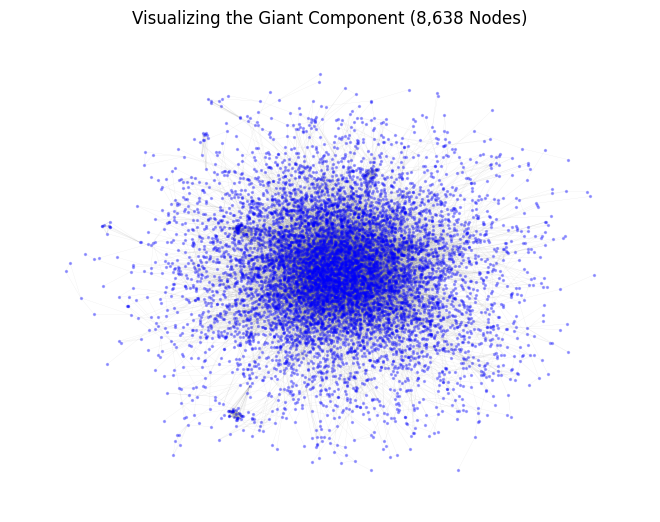

In [50]:
pos = nx.spring_layout(lcc, k=0.15, iterations=20) 
# Draw with high transparency (alpha) so you can see the density
nx.draw(lcc, pos, 
        node_size=2,          # Tiny nodes
        width=0.1,            # Very thin lines
        node_color='blue', 
        edge_color='gray', 
        alpha=0.3,            # Transparent so overlaps show density
        with_labels=False)
plt.title("Visualizing the Giant Component (8,638 Nodes)")
plt.show()

Calculating graph Average clustering coefficient:

In [ ]:
avg_clus = nx.average_clustering(lcc)
print(f'Average clustering coefficient: {avg_clus:.4f}')


Average clustering coefficient: 0.4816


### Average clustering coefficient: 0.4816 means the people in this giant island network is **highly connected** and very likely to know each other ~ 48% that two people in this network island are associated.